In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Currently using {DEVICE}")

Currently using cuda


In [3]:
from src.data_import import load_fashion_mnist, load_mnist_digit, load_CIFAR10, load_olivetti

train_loader, test_loader = load_olivetti(4, shuffle=True)

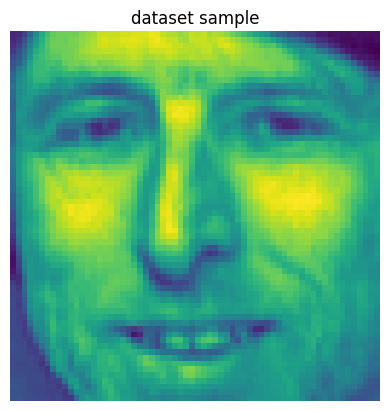

label: 38
shape: torch.Size([4, 1, 64, 64])


In [4]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="viridis")
#print label
print("label:", _[0].item())
print("shape:", x_real.shape)

In [5]:
from src.model import EnergyHead, EBM, SmallEBM

n_heads = 8
IMAGE_SHAPE = (1, 64, 64)

model = EBM(image_shape=IMAGE_SHAPE, mid_dim=150, n_heads=n_heads, batch_size=32)

model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-7): 8 x EnergyHead(
      (conv): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
      )
      (fc): Sequential(
        (0): Linear(in_features=16384, out_features=49, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

In [6]:
from src.sampler import ReplaySampler
from src.information import TotalCorrelationEstimator

sampler = ReplaySampler(model, img_shape=IMAGE_SHAPE, buffer_size=600, noise_fraction=0.05, device=DEVICE)
total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=64)
total_correlation_estimator.to(DEVICE)

In [7]:
from src.train import train_one_epoch_TC
#torch.autograd.set_detect_anomaly(True, check_nan=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.0, 0.999))

for epoch in range(16):
    epoch_loss = train_one_epoch_TC(

        model, 
        total_correlation_estimator, 
        sampler, 
        train_loader, 
        optimizer,

        sample_steps=60,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=1.0,
        tc_reg=1e-4,

        device=DEVICE
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

  9%|▊         | 6/70 [00:05<01:01,  1.04it/s]


KeyboardInterrupt: 

In [ ]:
from src.diagnostic import diagnose

diagnose(model, sampler, IMAGE_SHAPE, train_loader, test_loader, device=DEVICE, n_samples=16)

In [ ]:
samples = sampler.generate(10, steps=600, step_size=10.0, noise_std=0.005)

In [ ]:
show_grid(samples, 10)

In [ ]:
from src.plot import visualize_heads

fig = visualize_heads(model, sampler.buffer, IMAGE_SHAPE, DEVICE, k=4, cmap="viridis")

In [ ]:
def visualize_head_gradients(model, x, device, idx=0):
    """
    Per una singola immagine, mostra dE_i/dx per ogni testa.
    Rivela cosa "guarda" ogni testa nell'immagine.
    """
    model.eval()
    img = x[idx].unsqueeze(0).to(device)  # (1, 1, 28, 28)

    n_heads = len(model.heads)
    fig, axes = plt.subplots(1, n_heads + 1, figsize=(3 * (n_heads + 1), 3))

    # Immagine originale
    axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")

    for i, head in enumerate(model.heads):
        x_ = img.detach().requires_grad_(True)
        with torch.enable_grad():
            e = head(x_).sum()
            g = torch.autograd.grad(e, x_, only_inputs=True)[0]

        g_np = g.squeeze().cpu().detach().numpy()
        g_np = np.abs(g_np)
        g_np = (g_np - g_np.min()) / (g_np.max() - g_np.min() + 1e-8)

        axes[i + 1].imshow(g_np, cmap="hot")
        axes[i + 1].set_title(f"Head {i}\n|dE/dx|")
        axes[i + 1].axis("off")

    plt.suptitle("Gradient maps per testa", fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
x0 = iter(test_loader).__next__()[0]
visualize_head_gradients(model, x0, DEVICE)
